# Анализ поздних (постковидных) осложнений

Цель работы — оценить поздние осложнения COVID-19 в зависимости от тяжести перенесённого
заболевания и выделить **группы риска** по основным клиническим факторам.

Анализ построен в два этапа (по постановке научного руководителя):

**Этап 1. Осложнения в зависимости от тяжести.**
Частота каждого осложнения по группам КТ (КТ0 / КТ1 / КТ2 / КТ3–4), проверка тренда
«тяжесть → риск» и ранжирование основных признаков, влияющих на общий риск поздних осложнений.

**Этап 2. Группы риска.**
Как факторы — пол, возраст, ИМТ, HOMA, сопутствующие болезни, вакцинация, АД, температура,
бактериальные осложнения (вторичная инфекция), ОРДС, дыхательная недостаточность, ГКС (гормоны) —
влияли на конкретные осложнения: пневмофиброз, повторные пневмонии, ХОБЛ/бронхиальную астму,
ЖКТ/НЖБП, СД/эндокринные заболевания, ССЗ, операции на венах и, в первую очередь, **ОНМК/ИМ**.

> **Источник данных.** `updated_data.xlsx`, лист `0бщ.755` — общая выборка 755 пациентов.
> Поздние осложнения закодированы в столбцах `DZ..EO`.

**Методика.** Для каждого осложнения частота и отношения шансов (OR) с 95% доверительными
интервалами оценены логистической регрессией; тренд по тяжести — логистической регрессией на
порядковую группу КТ. Для частых исходов дополнительно построены многофакторные модели и
предсказательные ML-модели с кросс-валидацией. Для редких исходов (< ~50 событий) приводятся
только однофакторные оценки с оговоркой о малой выборке (ML статистически некорректен).


## 0.1 Подготовка окружения

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from IPython.display import display

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
RANDOM_STATE = 42
print('Окружение готово')

Окружение готово


## 0.2 Загрузка данных и формирование переменных

Загружаем лист `0бщ.755`. Осложнения приводим к бинарному виду (0 — нет, 1 — есть; значения 2+
означают несколько эпизодов и тоже считаются «есть»). Группа тяжести КТ формируется из `КТ(ИТОГ)`
объединением степеней 3 и 4 (КТ3–4) ввиду малочисленности крайней группы.

In [2]:
FILE_PATH = 'updated_data.xlsx'
SHEET = '0бщ.755'
df = pd.read_excel(FILE_PATH, sheet_name=SHEET, header=0)
N = len(df)
print(f'Загружено: {N} пациентов, {df.shape[1]} столбцов')

def col(i):
    """Числовой столбец по позиционному индексу."""
    return pd.to_numeric(df.iloc[:, i], errors='coerce')

def binarize(i):
    """Бинаризация столбца: >0 -> 1."""
    return (col(i).fillna(0) > 0).astype(int)

# --- осложнения-исходы (idx -> подпись) ---
COMP_IDX = {
    142: 'Пневмофиброз',
    140: 'Повторные пневмонии',
    143: 'ХОБЛ / бр. астма',
    144: 'ЖКТ / НЖБП',
    134: 'СД / эндокринные',
    130: 'ССЗ (новые)',
    132: 'Операции на венах',
    141: 'ОНМК / ИМ',
}
OVERALL_IDX = 129  # общий флаг поздних осложнений

comp = pd.DataFrame({name: binarize(i) for i, name in COMP_IDX.items()})
comp['Любое осложнение'] = binarize(OVERALL_IDX)

# --- группа тяжести по КТ(ИТОГ) ---
kt = col(38)
kt_grp = np.where(kt >= 3, 3, kt)
KT_LABELS = {0: 'КТ0', 1: 'КТ1', 2: 'КТ2', 3: 'КТ3-4'}
kt_grp = pd.Series(kt_grp, index=df.index).map(KT_LABELS)
kt_order = ['КТ0', 'КТ1', 'КТ2', 'КТ3-4']
print('Группы тяжести:', kt_grp.value_counts().reindex(kt_order).to_dict())

Загружено: 755 пациентов, 168 столбцов
Группы тяжести: {'КТ0': 303, 'КТ1': 246, 'КТ2': 142, 'КТ3-4': 64}


### Факторы риска

Непрерывные факторы используются «как есть» (в OR-оценках стандартизуются — OR на 1 стандартное
отклонение), бинарные — 0/1. Пол кодируется как «женский = 1». Бактериальные осложнения и
дыхательную недостаточность бинаризуем (наличие / отсутствие). Дополнительно вводится суммарное
число сопутствующих заболеваний.

In [3]:
# спецификация факторов: подпись -> (индекс, тип)
#   cont   — непрерывный (в OR стандартизуется)
#   bin    — бинарный >0
#   bin_f  — пол: женский=1 (исходно 1/2)
FACTOR_SPEC = [
    ('Возраст',            2,   'cont'),
    ('Пол (жен.)',         3,   'bin_f'),
    ('ИМТ',                31,  'cont'),
    ('HOMA',               114, 'cont'),
    ('АД сист.',           34,  'cont'),
    ('АД диаст.',          35,  'cont'),
    ('Температура',        20,  'cont'),
    ('Вакцинация',         10,  'bin'),
    ('Бактер. осложн.',    119, 'bin'),
    ('ОРДС',               109, 'bin'),
    ('Дых. недост. (ДН)',  103, 'bin'),
    ('ГКС (гормоны)',      92,  'bin'),
    ('Сопут.: ССС',        82,  'bin'),
    ('Сопут.: орг. дых.',  83,  'bin'),
    ('Сопут.: СД',         84,  'bin'),
    ('Сопут.: ЖКТ',        85,  'bin'),
]
COMORB_IDX = [82, 83, 84, 85, 86, 87, 88, 89]

def make_factor(idx, kind):
    if kind == 'cont':
        s = col(idx)
        return s.fillna(s.median())
    if kind == 'bin_f':
        return (col(idx) == 2).astype(int)
    return binarize(idx)  # 'bin'

factors = pd.DataFrame({name: make_factor(idx, kind) for name, idx, kind in FACTOR_SPEC})
factors['Число сопутств.'] = pd.concat([binarize(i) for i in COMORB_IDX], axis=1).sum(axis=1)

# какие факторы непрерывные (для стандартизации в OR)
CONT = {name for name, _, kind in FACTOR_SPEC if kind == 'cont'} | {'Число сопутств.'}
FACTOR_NAMES = list(factors.columns)
print(f'Факторов риска: {len(FACTOR_NAMES)}')
display(factors.describe().T[['mean', 'std', 'min', 'max']])

Факторов риска: 17


,mean,std,min,max
Возраст,37.866,12.789,18.000,80.000
Пол (жен.),0.408,0.492,0.000,1.000
ИМТ,27.106,3.922,17.800,40.200
HOMA,2.031,1.884,0.330,16.210
АД сист.,139.311,16.787,100.000,212.000
АД диаст.,99.196,14.400,60.000,149.000
Температура,37.992,0.901,28.400,40.300
Вакцинация,0.428,0.495,0.000,1.000
Бактер. осложн.,0.297,0.457,0.000,1.000
ОРДС,0.098,0.298,0.000,1.000


### Вспомогательные функции (OR, тренд)

In [4]:
def or_univariate(y, x, continuous):
    """Однофакторное OR (95% ДИ, p) логистической регрессией.
    continuous=True -> стандартизация, OR на 1 SD."""
    xv = (x - x.mean()) / x.std() if continuous else x.astype(float)
    X = sm.add_constant(pd.DataFrame({'x': xv}))
    try:
        r = sm.Logit(y, X).fit(disp=0)
        ci = np.exp(r.conf_int()).iloc[1]
        return np.exp(r.params.iloc[1]), ci.iloc[0], ci.iloc[1], r.pvalues.iloc[1]
    except Exception:
        return np.nan, np.nan, np.nan, np.nan

def trend_test(y, kt_numeric):
    """Тренд «тяжесть -> риск»: OR на одну ступень КТ + p."""
    X = sm.add_constant(pd.DataFrame({'kt': kt_numeric.astype(float)}))
    try:
        r = sm.Logit(y, X).fit(disp=0)
        return np.exp(r.params.iloc[1]), r.pvalues.iloc[1]
    except Exception:
        return np.nan, np.nan

def stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''

print('OK')

OK


## 0.3 Описание выборки осложнений

,Случаев,"Частота, %"
Любое осложнение,357,47.300
ЖКТ / НЖБП,191,25.300
Повторные пневмонии,171,22.600
ССЗ (новые),111,14.700
Операции на венах,52,6.900
СД / эндокринные,38,5.000
Пневмофиброз,35,4.600
ОНМК / ИМ,26,3.400
ХОБЛ / бр. астма,24,3.200


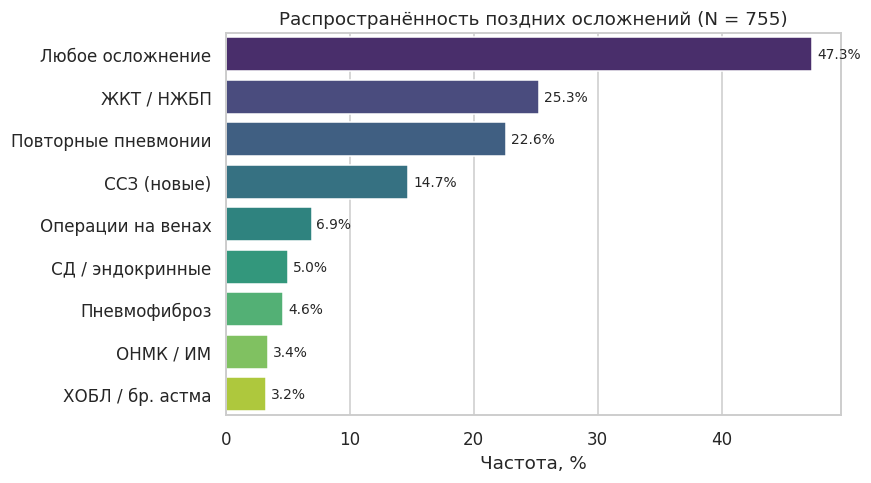

In [5]:
prev = pd.DataFrame({
    'Случаев': comp.sum().astype(int),
    'Частота, %': (100 * comp.mean()).round(1),
}).sort_values('Случаев', ascending=False)
display(prev)

fig, ax = plt.subplots(figsize=(8, 4.5))
order = prev.index.tolist()
sns.barplot(x=prev['Частота, %'], y=order, hue=order, palette='viridis', legend=False, ax=ax)
for i, v in enumerate(prev['Частота, %']):
    ax.text(v + 0.4, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Частота, %'); ax.set_ylabel('')
ax.set_title('Распространённость поздних осложнений (N = %d)' % N)
plt.tight_layout(); plt.show()

# ЭТАП 1. Осложнения в зависимости от тяжести (КТ)

Оцениваем, как частота каждого осложнения меняется по группам тяжести лёгочного поражения,
и проверяем статистическую значимость тренда.

## 1.1 Частота осложнений по группам КТ

In [6]:
by_kt = comp.drop(columns=['Любое осложнение']).groupby(kt_grp).mean().reindex(kt_order) * 100
grp_sizes = kt_grp.value_counts().reindex(kt_order)

tbl = by_kt.T.round(1)
tbl.columns = [f'{c} (n={int(grp_sizes[c])})' for c in tbl.columns]
print('Частота осложнения, % по группам тяжести КТ:')
display(tbl)

Частота осложнения, % по группам тяжести КТ:


,КТ0 (n=303),КТ1 (n=246),КТ2 (n=142),КТ3-4 (n=64)
Пневмофиброз,0.700,2.000,6.300,29.700
Повторные пневмонии,15.200,24.000,27.500,42.200
ХОБЛ / бр. астма,1.300,2.400,4.200,12.500
ЖКТ / НЖБП,11.200,26.800,41.500,50.000
СД / эндокринные,3.000,2.400,11.300,10.900
ССЗ (новые),9.200,14.200,22.500,25.000
Операции на венах,2.600,6.100,10.600,21.900
ОНМК / ИМ,1.000,1.600,7.700,12.500


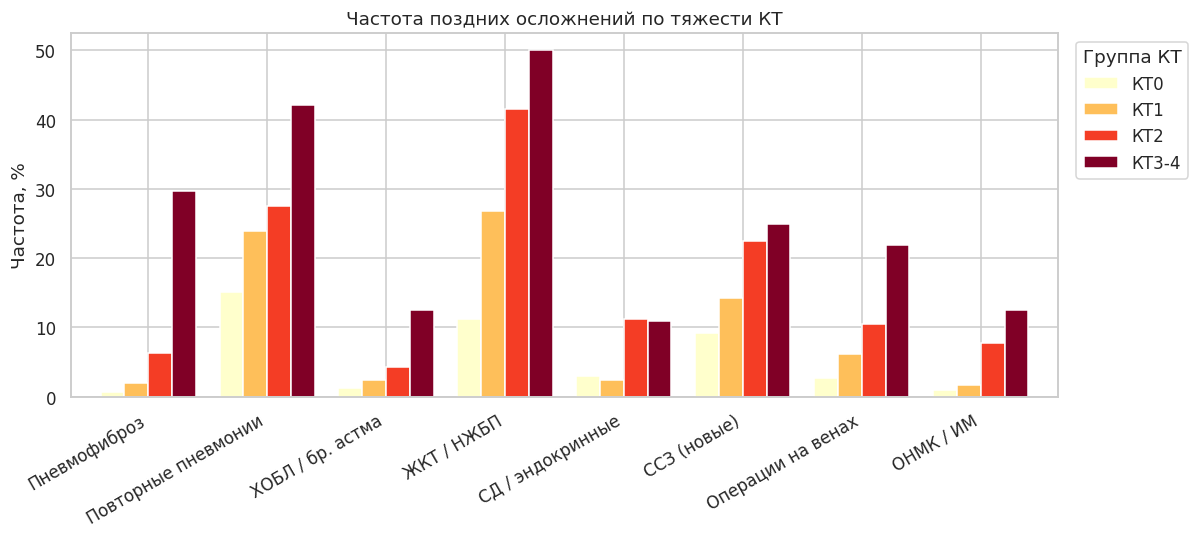

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
by_kt.T.plot(kind='bar', ax=ax, colormap='YlOrRd', width=0.8)
ax.set_ylabel('Частота, %'); ax.set_xlabel('')
ax.set_title('Частота поздних осложнений по тяжести КТ')
ax.legend(title='Группа КТ', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

## 1.2 Тест тренда «тяжесть → риск»

,Осложнение,OR на ступень КТ,p,знач.
0,Пневмофиброз,4.360,0.000,***
1,ОНМК / ИМ,2.644,0.000,***
2,ХОБЛ / бр. астма,2.198,0.000,***
3,Операции на венах,2.123,0.000,***
4,ЖКТ / НЖБП,2.064,0.000,***
5,СД / эндокринные,1.841,0.000,***
6,ССЗ (новые),1.549,0.000,***
7,Повторные пневмонии,1.533,0.000,***


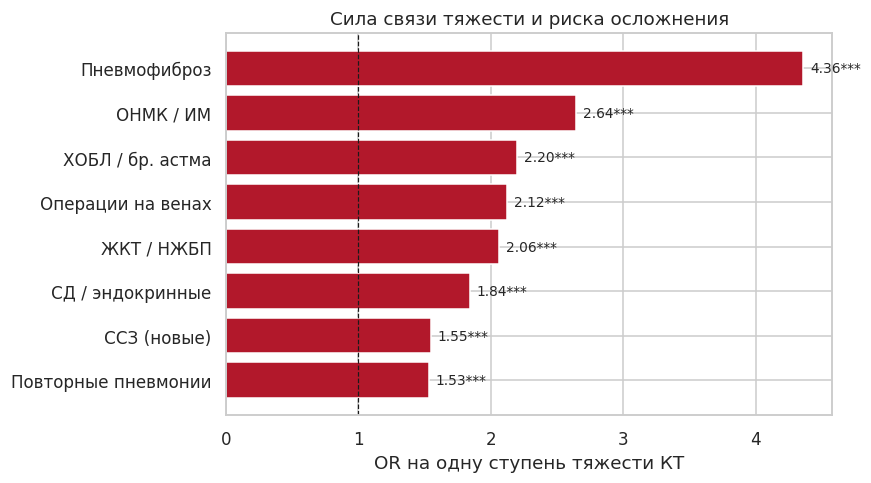

In [8]:
kt_num = pd.Series(np.where(kt >= 3, 3, kt), index=df.index)
rows = []
for name in COMP_IDX.values():
    orr, p = trend_test(comp[name], kt_num)
    rows.append((name, orr, p, stars(p)))
trend = pd.DataFrame(rows, columns=['Осложнение', 'OR на ступень КТ', 'p', 'знач.'])
trend = trend.sort_values('OR на ступень КТ', ascending=False).reset_index(drop=True)
display(trend)

fig, ax = plt.subplots(figsize=(8, 4.5))
t = trend.sort_values('OR на ступень КТ')
colors = ['#b2182b' if p < 0.05 else '#bdbdbd' for p in t['p']]
ax.barh(t['Осложнение'], t['OR на ступень КТ'], color=colors)
ax.axvline(1, color='k', lw=0.8, ls='--')
for y_, (orr, st) in enumerate(zip(t['OR на ступень КТ'], t['знач.'])):
    ax.text(orr + 0.05, y_, f'{orr:.2f}{st}', va='center', fontsize=9)
ax.set_xlabel('OR на одну ступень тяжести КТ')
ax.set_title('Сила связи тяжести и риска осложнения')
plt.tight_layout(); plt.show()

Все осложнения демонстрируют статистически значимый рост частоты с увеличением тяжести КТ
(p < 0.001). Наиболее «зависимы от тяжести» пневмофиброз, ОНМК/ИМ, операции на венах и ХОБЛ/астма.

## 1.3 Основные признаки, влияющие на риск поздних осложнений

За исход берём общий флаг «любое позднее осложнение» (≈47% пациентов). Сначала однофакторные OR,
затем многофакторная логистическая модель (скорректированные OR) и, для устойчивости, важность
признаков по случайному лесу с кросс-валидацией.

In [9]:
y_any = comp['Любое осложнение']

# --- однофакторные OR ---
rows = []
for name in FACTOR_NAMES:
    orr, lo, hi, p = or_univariate(y_any, factors[name], name in CONT)
    rows.append((name, orr, lo, hi, p, stars(p)))
uni_any = pd.DataFrame(rows, columns=['Фактор', 'OR', 'ДИ low', 'ДИ high', 'p', 'знач.'])
uni_any['ед.'] = ['на 1 SD' if n in CONT else '0/1' for n in uni_any['Фактор']]
uni_any = uni_any.sort_values('p').reset_index(drop=True)
print('Однофакторные OR факторов риска для «любого позднего осложнения»:')
display(uni_any)

Однофакторные OR факторов риска для «любого позднего осложнения»:


,Фактор,OR,ДИ low,ДИ high,p,знач.,ед.
0,Возраст,3.042,2.511,3.685,0.000,***,на 1 SD
1,ИМТ,2.956,2.429,3.597,0.000,***,на 1 SD
2,HOMA,5.560,4.030,7.671,0.000,***,на 1 SD
3,ГКС (гормоны),5.108,3.725,7.004,0.000,***,0/1
4,Число сопутств.,2.349,1.978,2.789,0.000,***,на 1 SD
5,АД сист.,2.339,1.961,2.791,0.000,***,на 1 SD
6,Бактер. осложн.,4.787,3.392,6.756,0.000,***,0/1
7,Дых. недост. (ДН),5.419,3.734,7.865,0.000,***,0/1
8,АД диаст.,2.103,1.775,2.492,0.000,***,на 1 SD
9,Сопут.: ЖКТ,3.272,2.424,4.416,0.000,***,0/1


Многофакторная модель: скорректированные OR (псевдо-R2 = 0.298)


,OR (скорр.),ДИ low,ДИ high,p,знач.
Возраст,2.158,1.687,2.759,0.000,***
HOMA,2.552,1.777,3.663,0.000,***
ГКС (гормоны),2.431,1.508,3.919,0.000,***
ИМТ,1.344,1.024,1.765,0.033,*
Сопут.: ССС,0.550,0.308,0.980,0.042,*
ОРДС,1.794,0.712,4.516,0.215,
Бактер. осложн.,1.310,0.806,2.128,0.276,
Пол (жен.),1.147,0.767,1.715,0.504,
АД диаст.,0.899,0.638,1.267,0.544,
АД сист.,1.112,0.773,1.599,0.567,


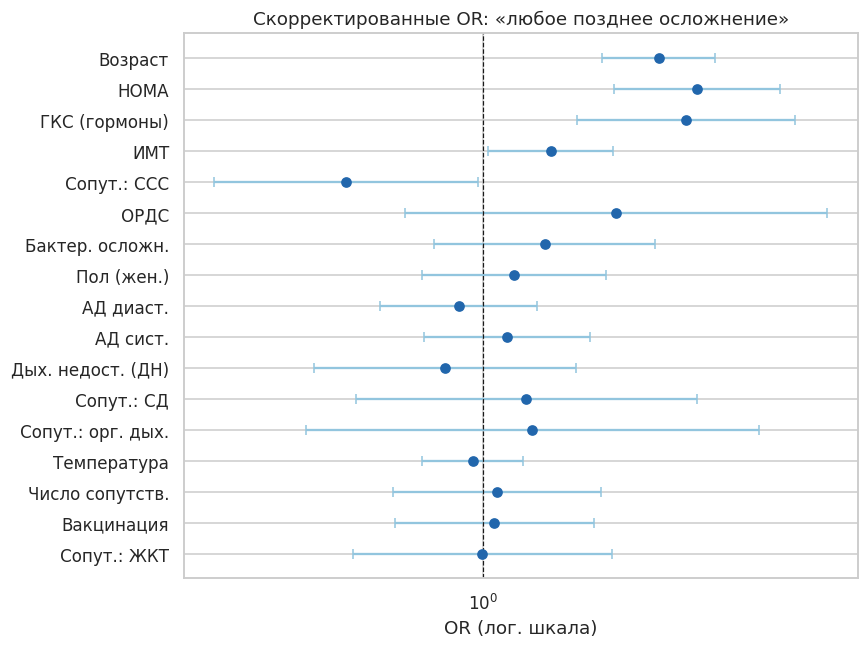

In [10]:
# --- многофакторная логистическая модель (скорректированные OR) ---
Xm = factors.copy()
for c in CONT:
    Xm[c] = (Xm[c] - Xm[c].mean()) / Xm[c].std()
Xm = sm.add_constant(Xm)
mod_any = sm.Logit(y_any, Xm).fit(disp=0)
adj = pd.DataFrame({
    'OR (скорр.)': np.exp(mod_any.params),
    'ДИ low': np.exp(mod_any.conf_int()[0]),
    'ДИ high': np.exp(mod_any.conf_int()[1]),
    'p': mod_any.pvalues,
}).drop(index='const')
adj['знач.'] = adj['p'].map(stars)
adj = adj.sort_values('p')
print('Многофакторная модель: скорректированные OR (псевдо-R2 = %.3f)' % mod_any.prsquared)
display(adj)

# forest-plot скорректированных OR
fig, ax = plt.subplots(figsize=(8, 6))
a = adj.iloc[::-1]
ypos = np.arange(len(a))
ax.errorbar(a['OR (скорр.)'], ypos,
            xerr=[a['OR (скорр.)'] - a['ДИ low'], a['ДИ high'] - a['OR (скорр.)']],
            fmt='o', color='#2166ac', ecolor='#92c5de', capsize=3)
ax.axvline(1, color='k', lw=0.8, ls='--')
ax.set_yticks(ypos); ax.set_yticklabels(a.index)
ax.set_xscale('log'); ax.set_xlabel('OR (лог. шкала)')
ax.set_title('Скорректированные OR: «любое позднее осложнение»')
plt.tight_layout(); plt.show()

RandomForest, CV ROC-AUC = 0.816 ± 0.049


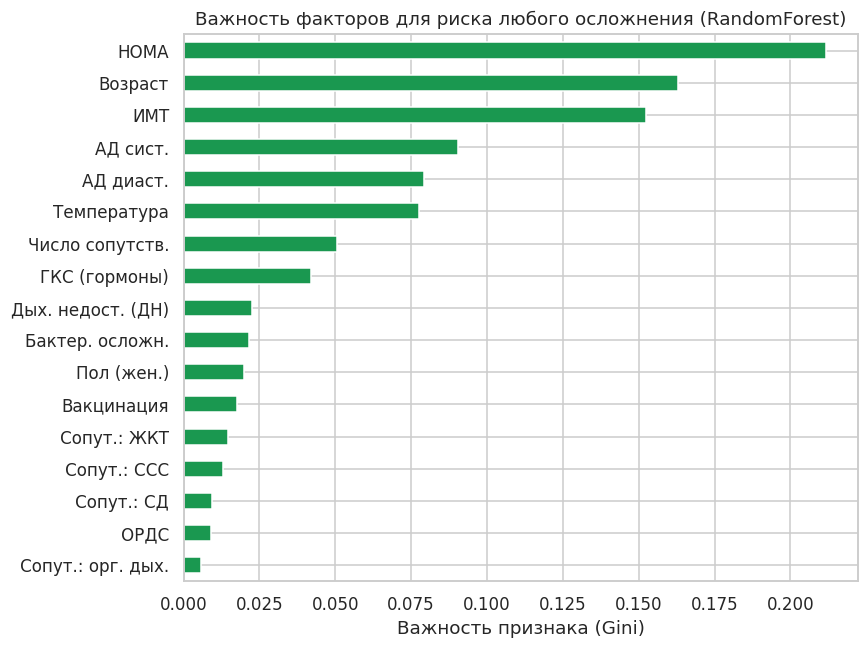

In [11]:
# --- важность по случайному лесу + CV ROC-AUC (устойчивость ранжирования) ---
rf = RandomForestClassifier(n_estimators=400, class_weight='balanced',
                            random_state=RANDOM_STATE, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
auc = cross_val_score(rf, factors.values, y_any, cv=cv, scoring='roc_auc')
print(f'RandomForest, CV ROC-AUC = {auc.mean():.3f} ± {auc.std():.3f}')

rf.fit(factors.values, y_any)
imp = pd.Series(rf.feature_importances_, index=FACTOR_NAMES).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
imp.plot(kind='barh', color='#1a9850', ax=ax)
ax.set_xlabel('Важность признака (Gini)')
ax.set_title('Важность факторов для риска любого осложнения (RandomForest)')
plt.tight_layout(); plt.show()

# ЭТАП 2. Группы риска: влияние факторов на конкретные осложнения

Для каждого осложнения оцениваем, как связаны с ним факторы риска. Базовый инструмент —
отношение шансов (OR): для непрерывных факторов на 1 SD, для бинарных — наличие/отсутствие.

## 2.1 Матрица отношений шансов (фактор × осложнение)

Тепловая карта `log2(OR)`: красный — фактор повышает риск, синий — снижает. Звёздочкой отмечены
значимые связи (p < 0.05).

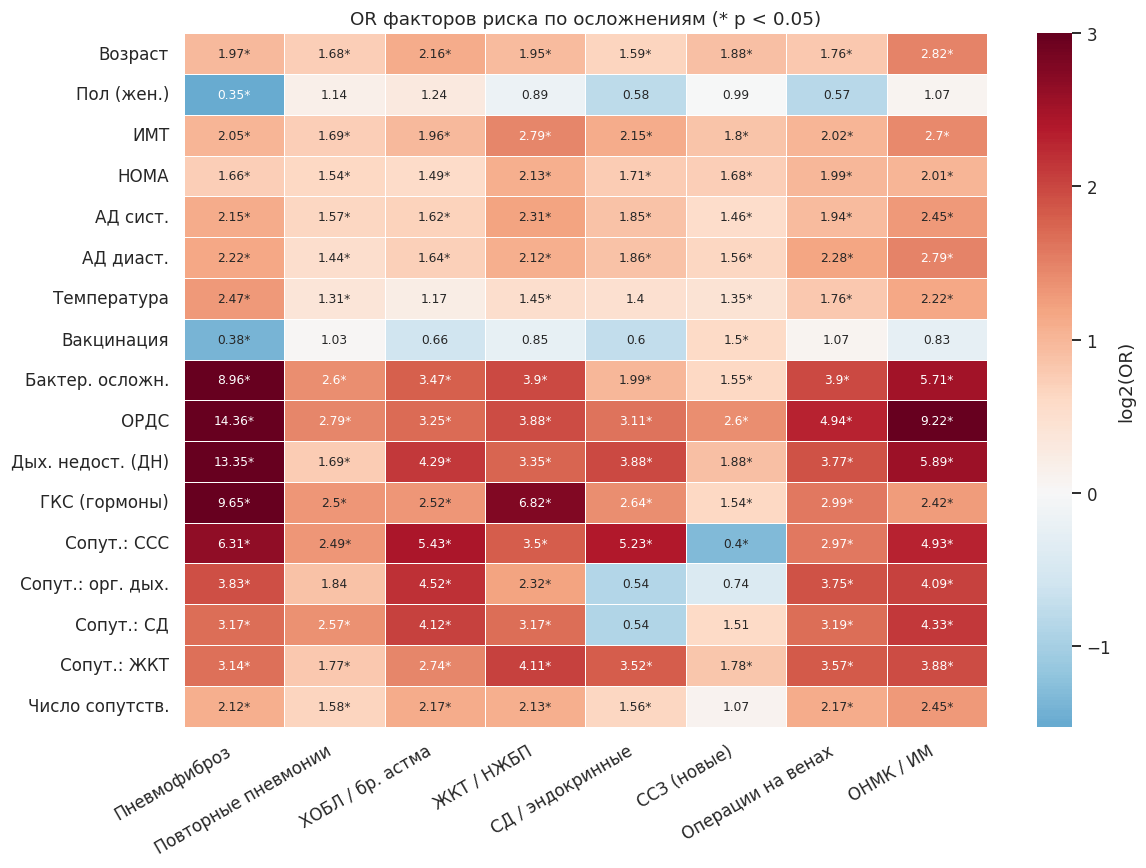

In [12]:
comp8 = list(COMP_IDX.values())
or_mat = pd.DataFrame(index=FACTOR_NAMES, columns=comp8, dtype=float)
p_mat = pd.DataFrame(index=FACTOR_NAMES, columns=comp8, dtype=float)
for cname in comp8:
    for fname in FACTOR_NAMES:
        orr, lo, hi, p = or_univariate(comp[cname], factors[fname], fname in CONT)
        or_mat.loc[fname, cname] = orr
        p_mat.loc[fname, cname] = p

log2or = np.log2(or_mat.astype(float)).clip(-3, 3)
annot = or_mat.astype(float).round(2).astype(str)
annot = annot.where(p_mat >= 0.05, annot + '*')

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(log2or, annot=annot, fmt='', cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={'label': 'log2(OR)'}, ax=ax,
            annot_kws={'fontsize': 8})
ax.set_title('OR факторов риска по осложнениям (* p < 0.05)')
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

In [13]:
# наиболее сильные значимые связи (по всей матрице)
pairs = []
for cname in comp8:
    for fname in FACTOR_NAMES:
        orr, p = or_mat.loc[fname, cname], p_mat.loc[fname, cname]
        if p < 0.05 and np.isfinite(orr):
            pairs.append((fname, cname, orr, p))
top = pd.DataFrame(pairs, columns=['Фактор', 'Осложнение', 'OR', 'p'])
top['|эффект|'] = np.abs(np.log2(top['OR']))
top = top.sort_values('|эффект|', ascending=False).drop(columns='|эффект|').head(20).reset_index(drop=True)
print('Топ-20 самых сильных значимых связей фактор → осложнение:')
display(top)

Топ-20 самых сильных значимых связей фактор → осложнение:


,Фактор,Осложнение,OR,p
0,ОРДС,Пневмофиброз,14.358,0.000
1,Дых. недост. (ДН),Пневмофиброз,13.349,0.000
2,ГКС (гормоны),Пневмофиброз,9.652,0.000
3,ОРДС,ОНМК / ИМ,9.221,0.000
4,Бактер. осложн.,Пневмофиброз,8.960,0.000
5,ГКС (гормоны),ЖКТ / НЖБП,6.819,0.000
6,Сопут.: ССС,Пневмофиброз,6.306,0.000
7,Дых. недост. (ДН),ОНМК / ИМ,5.891,0.000
8,Бактер. осложн.,ОНМК / ИМ,5.712,0.000
9,Сопут.: ССС,ХОБЛ / бр. астма,5.435,0.000


## 2.2 Многофакторная логистическая регрессия (частые исходы)

Для осложнений с достаточным числом случаев (повторные пневмонии, ЖКТ/НЖБП, ССЗ) строим
многофакторные модели — скорректированные OR показывают независимый вклад каждого фактора.

> **Как читать скорректированные OR.** В многофакторной модели знак эффекта может отличаться от
> однофакторного: `OR < 1` означает, что *при прочих равных* фактор связан с **понижением** шансов.
> Такой разворот знака — следствие взаимной корреляции факторов (отрицательное конфаундинг) либо
> особенностей определения исхода, и не противоречит однофакторным оценкам, а уточняет их.

In [14]:
FREQUENT = ['Повторные пневмонии', 'ЖКТ / НЖБП', 'ССЗ (новые)']

def multivariable(cname):
    X = factors.copy()
    for c in CONT:
        X[c] = (X[c] - X[c].mean()) / X[c].std()
    X = sm.add_constant(X)
    m = sm.Logit(comp[cname], X).fit(disp=0)
    out = pd.DataFrame({
        'OR (скорр.)': np.exp(m.params),
        'ДИ low': np.exp(m.conf_int()[0]),
        'ДИ high': np.exp(m.conf_int()[1]),
        'p': m.pvalues,
    }).drop(index='const')
    out['знач.'] = out['p'].map(stars)
    return out, m.prsquared

for cname in FREQUENT:
    res, pr2 = multivariable(cname)
    sig = res[res['p'] < 0.05].sort_values('p')
    print(f'\n=== {cname}  (случаев={int(comp[cname].sum())}, псевдо-R2={pr2:.3f}) ===')
    print('Значимые независимые предикторы:')
    display(sig if len(sig) else res.sort_values('p').head(5))


=== Повторные пневмонии  (случаев=171, псевдо-R2=0.097) ===
Значимые независимые предикторы:


,OR (скорр.),ДИ low,ДИ high,p,знач.
Дых. недост. (ДН),0.366,0.199,0.673,0.001,**
Возраст,1.349,1.068,1.705,0.012,*
ГКС (гормоны),1.850,1.115,3.068,0.017,*
Бактер. осложн.,1.777,1.090,2.897,0.021,*



=== ЖКТ / НЖБП  (случаев=191, псевдо-R2=0.250) ===
Значимые независимые предикторы:


,OR (скорр.),ДИ low,ДИ high,p,знач.
ГКС (гормоны),5.636,3.280,9.684,0.000,***
ИМТ,1.664,1.265,2.190,0.000,***
АД сист.,1.638,1.128,2.377,0.009,**
HOMA,1.296,1.030,1.630,0.027,*
Дых. недост. (ДН),0.554,0.311,0.988,0.045,*



=== ССЗ (новые)  (случаев=111, псевдо-R2=0.272) ===
Значимые независимые предикторы:


,OR (скорр.),ДИ low,ДИ high,p,знач.
Сопут.: ССС,0.031,0.012,0.078,0.000,***
Возраст,2.546,1.858,3.488,0.000,***
ИМТ,1.822,1.305,2.542,0.000,***
HOMA,1.487,1.159,1.907,0.002,**


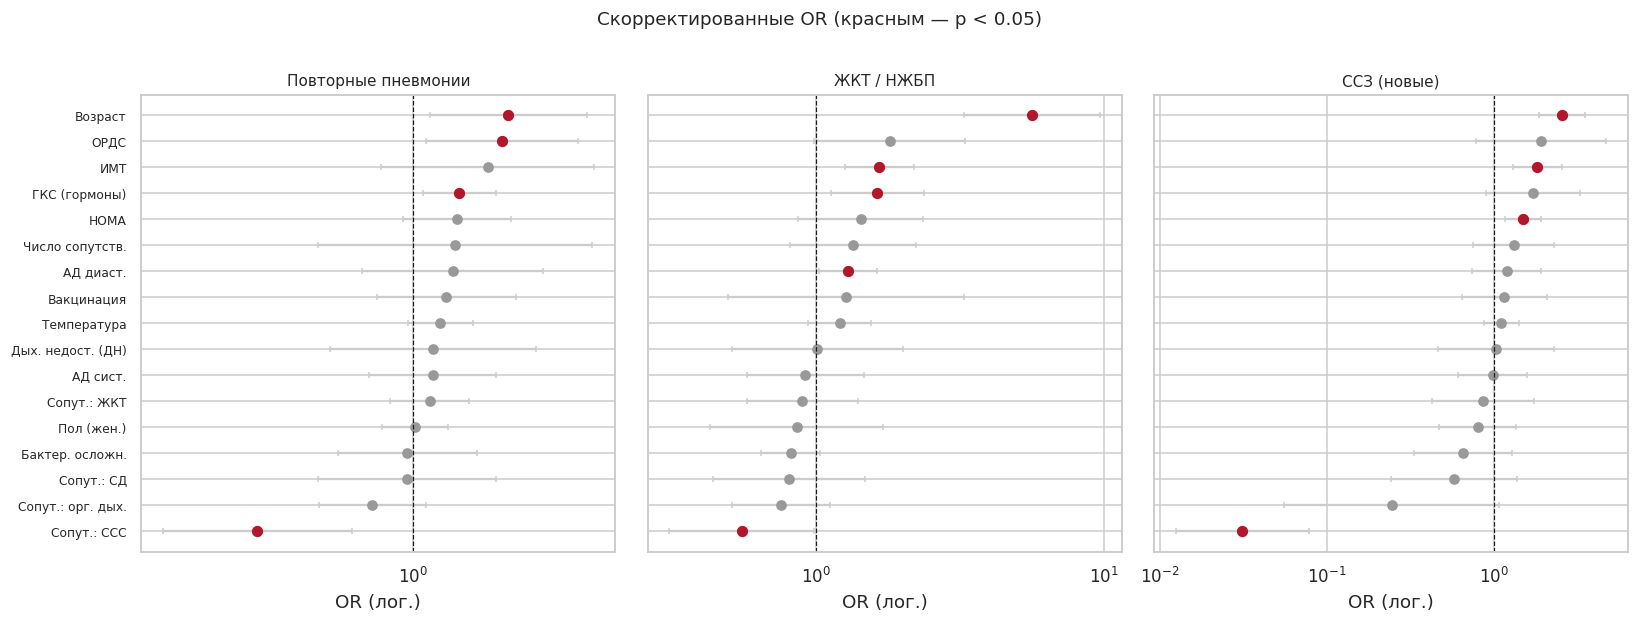

In [15]:
# forest-plot скорректированных OR для частых исходов
fig, axes = plt.subplots(1, len(FREQUENT), figsize=(15, 5.5), sharey=True)
for ax, cname in zip(axes, FREQUENT):
    res, _ = multivariable(cname)
    res = res.sort_values('OR (скорр.)')
    ypos = np.arange(len(res))
    sig = (res['p'] < 0.05).values
    ax.errorbar(res['OR (скорр.)'], ypos,
                xerr=[res['OR (скорр.)'] - res['ДИ low'], res['ДИ high'] - res['OR (скорр.)']],
                fmt='o', color='#999999', ecolor='#cccccc', capsize=2, zorder=1)
    ax.scatter(res['OR (скорр.)'].values[sig], ypos[sig], color='#b2182b', zorder=3, s=40)
    ax.axvline(1, color='k', lw=0.8, ls='--')
    ax.set_yticks(ypos); ax.set_yticklabels(res.index, fontsize=8)
    ax.set_xscale('log'); ax.set_xlabel('OR (лог.)')
    ax.set_title(cname, fontsize=10)
fig.suptitle('Скорректированные OR (красным — p < 0.05)', y=1.02)
plt.tight_layout(); plt.show()

## 2.3 Фокус: ОНМК / ИМ

Самое тяжёлое позднее осложнение (26 случаев, 3.4%). Ввиду редкости приводим профиль группы риска
(сравнение факторов у пациентов с осложнением и без) и однофакторные OR; многофакторные оценки
интерпретируем осторожно.

In [16]:
y_stroke = comp['ОНМК / ИМ']

# профиль группы риска: cases vs non-cases
prof = []
for name in FACTOR_NAMES:
    x = factors[name]
    if name in CONT:
        m1, m0 = x[y_stroke == 1].mean(), x[y_stroke == 0].mean()
        p = stats.mannwhitneyu(x[y_stroke == 1], x[y_stroke == 0]).pvalue
        prof.append((name, f'{m1:.1f}', f'{m0:.1f}', p, stars(p)))
    else:
        r1 = 100 * x[y_stroke == 1].mean(); r0 = 100 * x[y_stroke == 0].mean()
        tab = pd.crosstab(x, y_stroke)
        p = stats.fisher_exact(tab.values)[1] if tab.shape == (2, 2) else np.nan
        prof.append((name, f'{r1:.0f}%', f'{r0:.0f}%', p, stars(p)))
prof = pd.DataFrame(prof, columns=['Фактор', 'ОНМК/ИМ (есть)', 'ОНМК/ИМ (нет)', 'p', 'знач.'])
prof = prof.sort_values('p').reset_index(drop=True)
print('Профиль группы риска ОНМК/ИМ (среднее для непрерывных, доля для бинарных):')
display(prof)

Профиль группы риска ОНМК/ИМ (среднее для непрерывных, доля для бинарных):


,Фактор,ОНМК/ИМ (есть),ОНМК/ИМ (нет),p,знач.
0,HOMA,4.9,1.9,0.000,***
1,Возраст,50.8,37.4,0.000,***
2,ОРДС,46%,9%,0.000,***
3,Число сопутств.,2.6,1.4,0.000,***
4,АД сист.,156.9,138.7,0.000,***
5,Дых. недост. (ДН),65%,24%,0.000,***
6,ИМТ,31.3,27.0,0.000,***
7,Бактер. осложн.,69%,28%,0.000,***
8,АД диаст.,111.7,98.8,0.000,***
9,Сопут.: ССС,73%,36%,0.000,***


,Фактор,OR,ДИ low,ДИ high,p,знач.
0,ОРДС,9.221,4.087,20.807,0.000,***
1,Дых. недост. (ДН),5.891,2.580,13.449,0.000,***
2,Бактер. осложн.,5.712,2.446,13.342,0.000,***
3,Сопут.: ССС,4.926,2.044,11.872,0.000,***
4,Сопут.: СД,4.327,1.906,9.823,0.000,***
5,Сопут.: орг. дых.,4.094,1.330,12.603,0.014,*
6,Сопут.: ЖКТ,3.879,1.447,10.397,0.007,**
7,Возраст,2.819,1.872,4.247,0.000,***
8,АД диаст.,2.793,1.770,4.405,0.000,***
9,ИМТ,2.696,1.858,3.911,0.000,***


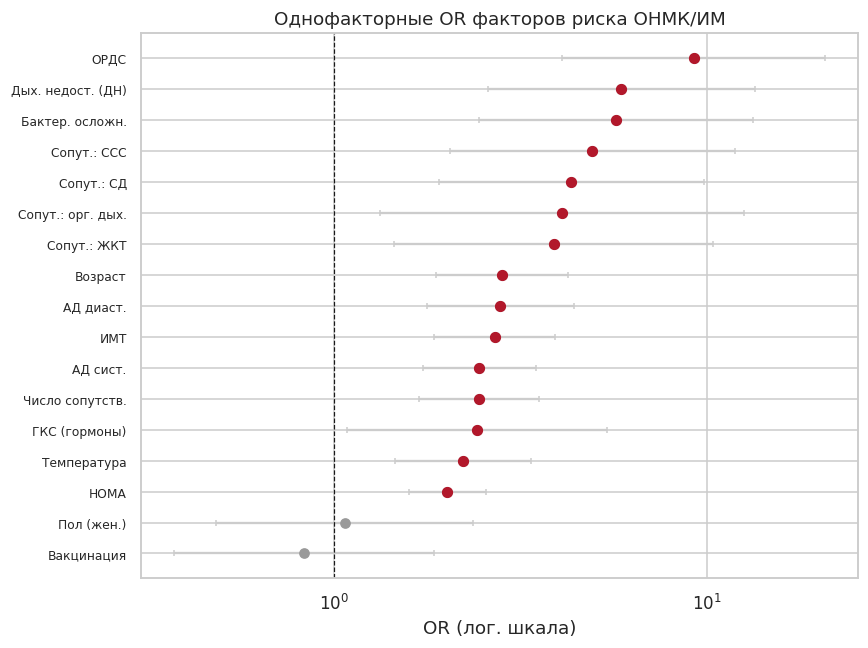

In [17]:
# однофакторные OR для ОНМК/ИМ
rows = []
for name in FACTOR_NAMES:
    orr, lo, hi, p = or_univariate(y_stroke, factors[name], name in CONT)
    rows.append((name, orr, lo, hi, p, stars(p)))
uni_s = pd.DataFrame(rows, columns=['Фактор', 'OR', 'ДИ low', 'ДИ high', 'p', 'знач.'])
uni_s = uni_s[np.isfinite(uni_s['OR'])].sort_values('OR', ascending=False).reset_index(drop=True)
display(uni_s)

fig, ax = plt.subplots(figsize=(8, 6))
a = uni_s.sort_values('OR')
ypos = np.arange(len(a))
sig = (a['p'] < 0.05).values
ax.errorbar(a['OR'], ypos, xerr=[a['OR'] - a['ДИ low'], a['ДИ high'] - a['OR']],
            fmt='o', color='#999999', ecolor='#cccccc', capsize=2)
ax.scatter(a['OR'].values[sig], ypos[sig], color='#b2182b', zorder=3, s=40)
ax.axvline(1, color='k', lw=0.8, ls='--')
ax.set_yticks(ypos); ax.set_yticklabels(a['Фактор'], fontsize=8)
ax.set_xscale('log'); ax.set_xlabel('OR (лог. шкала)')
ax.set_title('Однофакторные OR факторов риска ОНМК/ИМ')
plt.tight_layout(); plt.show()

## 2.4 Редкие осложнения — однофакторные OR

Пневмофиброз, ХОБЛ/астма, СД/эндокринные, операции на венах — < ~50 событий. Приводим только
значимые однофакторные связи; многофакторные ML-модели для них статистически не обоснованы.

In [18]:
RARE = ['Пневмофиброз', 'ХОБЛ / бр. астма', 'СД / эндокринные', 'Операции на венах']
for cname in RARE:
    rows = []
    for name in FACTOR_NAMES:
        orr, lo, hi, p = or_univariate(comp[cname], factors[name], name in CONT)
        rows.append((name, orr, lo, hi, p))
    t = pd.DataFrame(rows, columns=['Фактор', 'OR', 'ДИ low', 'ДИ high', 'p'])
    t = t[(t['p'] < 0.05) & np.isfinite(t['OR'])].sort_values('OR', ascending=False)
    print(f'\n=== {cname}  (случаев = {int(comp[cname].sum())}) — значимые факторы ===')
    display(t.reset_index(drop=True) if len(t) else 'значимых однофакторных связей не выявлено')


=== Пневмофиброз  (случаев = 35) — значимые факторы ===


,Фактор,OR,ДИ low,ДИ high,p
0,ОРДС,14.358,6.991,29.487,0.000
1,Дых. недост. (ДН),13.349,5.727,31.114,0.000
2,ГКС (гормоны),9.652,3.701,25.173,0.000
3,Бактер. осложн.,8.960,4.003,20.057,0.000
4,Сопут.: ССС,6.306,2.823,14.087,0.000
5,Сопут.: орг. дых.,3.833,1.389,10.576,0.009
6,Сопут.: СД,3.168,1.501,6.685,0.002
7,Сопут.: ЖКТ,3.140,1.407,7.004,0.005
8,Температура,2.467,1.701,3.577,0.000
9,АД диаст.,2.223,1.516,3.260,0.000



=== ХОБЛ / бр. астма  (случаев = 24) — значимые факторы ===


,Фактор,OR,ДИ low,ДИ high,p
0,Сопут.: ССС,5.435,2.131,13.861,0.000
1,Сопут.: орг. дых.,4.516,1.456,14.011,0.009
2,Дых. недост. (ДН),4.286,1.871,9.816,0.001
3,Сопут.: СД,4.116,1.751,9.674,0.001
4,Бактер. осложн.,3.473,1.519,7.943,0.003
5,ОРДС,3.250,1.248,8.463,0.016
6,Сопут.: ЖКТ,2.741,1.076,6.983,0.035
7,ГКС (гормоны),2.520,1.088,5.835,0.031
8,Число сопутств.,2.173,1.489,3.172,0.000
9,Возраст,2.161,1.440,3.243,0.000



=== СД / эндокринные  (случаев = 38) — значимые факторы ===


,Фактор,OR,ДИ low,ДИ high,p
0,Сопут.: ССС,5.230,2.500,10.943,0.000
1,Дых. недост. (ДН),3.884,2.004,7.530,0.000
2,Сопут.: ЖКТ,3.517,1.591,7.776,0.002
3,ОРДС,3.113,1.413,6.860,0.005
4,ГКС (гормоны),2.644,1.345,5.199,0.005
5,ИМТ,2.149,1.575,2.931,0.000
6,Бактер. осложн.,1.994,1.031,3.857,0.040
7,АД диаст.,1.856,1.299,2.650,0.001
8,АД сист.,1.851,1.381,2.480,0.000
9,HOMA,1.705,1.382,2.104,0.000



=== Операции на венах  (случаев = 52) — значимые факторы ===


,Фактор,OR,ДИ low,ДИ high,p
0,ОРДС,4.943,2.587,9.442,0.000
1,Бактер. осложн.,3.901,2.188,6.954,0.000
2,Дых. недост. (ДН),3.774,2.129,6.689,0.000
3,Сопут.: орг. дых.,3.750,1.553,9.054,0.003
4,Сопут.: ЖКТ,3.572,1.806,7.062,0.000
5,Сопут.: СД,3.189,1.697,5.991,0.000
6,ГКС (гормоны),2.993,1.657,5.406,0.000
7,Сопут.: ССС,2.972,1.665,5.308,0.000
8,АД диаст.,2.279,1.645,3.158,0.000
9,Число сопутств.,2.166,1.652,2.840,0.000


## 2.5 Предсказательные модели (только частые исходы)

Для исходов с достаточным числом случаев оцениваем предсказуемость по факторам риска: логистическая
регрессия и случайный лес, метрика — ROC-AUC по 5-блочной стратифицированной кросс-валидации
(честная оценка без переобучения; единичный train/test-сплит для редких событий неустойчив).

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models = {
    'Логит. регрессия': make_pipeline(StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    'Случайный лес': RandomForestClassifier(n_estimators=400, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),
}
rows = []
for cname in ['Любое осложнение'] + FREQUENT:
    y = comp[cname]
    row = {'Осложнение': cname, 'Случаев': int(y.sum())}
    for mname, mdl in models.items():
        s = cross_val_score(mdl, factors.values, y, cv=cv, scoring='roc_auc')
        row[mname] = f'{s.mean():.3f} ± {s.std():.3f}'
    rows.append(row)
display(pd.DataFrame(rows).set_index('Осложнение'))

,Случаев,Логит. регрессия,Случайный лес
Осложнение,,,
Любое осложнение,357,0.843 ± 0.043,0.816 ± 0.049
Повторные пневмонии,171,0.684 ± 0.052,0.660 ± 0.048
ЖКТ / НЖБП,191,0.813 ± 0.032,0.812 ± 0.032
ССЗ (новые),111,0.817 ± 0.033,0.845 ± 0.033


## 2.6 Поиск групп риска для каждого осложнения

Группы риска находим неглубоким деревом решений (глубина 2): оно разбивает пациентов на
подгруппы по сочетанию клинико-лабораторных признаков и выделяет подгруппу с максимальной частотой
осложнения. В предикторы добавлены **лабораторные показатели** (СРБ, ферритин, Д-димер, ЛДГ, ИЛ-6,
лейкоциты, СОЭ, глюкоза, креатинин, АЛТ, фибриноген), а также возраст, ИМТ, HOMA, SpO2, тяжесть КТ
и факторы течения (ОРДС, ДН, ГКС, бактериальные осложнения, вакцинация, пол).

Для каждой подгруппы приводится истинная частота осложнения, число пациентов и **lift** —
во сколько раз риск в подгруппе выше базового по всей выборке.

> **Оговорки.** (1) Частоты в подгруппах — **in-sample** (на тех же данных, без кросс-валидации),
> поэтому это *описание* выявленных групп риска, а не валидированный прогноз; реальная частота в новой
> выборке будет несколько ниже. (2) Здесь набор предикторов **шире**, чем в OR-анализе этапов 1.3–2.5:
> добавлены лабораторные показатели (ферритин, ЛДГ, Д-димер, ИЛ-6, СОЭ и др.), но не вынесены отдельно
> сопутствующие заболевания. Поэтому ведущие признаки тут (лабораторные) и в OR-матрице (течение и
> коморбидность) дополняют друг друга, а не противоречат.

In [20]:
from sklearn.tree import DecisionTreeClassifier, _tree

# --- панель лабораторных и клинических показателей (исходные/пиковые, без поздних анализов) ---
LAB_SPEC = [
    ('Возраст', 2), ('ИМТ', 31), ('SpO2 min', 33), ('КТ макс %', 39),
    ('Лейкоциты', 45), ('СОЭ', 50), ('СРБ', 74), ('Ферритин', 75), ('Д-димер', 76),
    ('ЛДГ', 73), ('АЛТ', 64), ('Креатинин', 68), ('Глюкоза макс', 66),
    ('HOMA', 114), ('ИЛ-6', 110), ('Фибриноген', 79),
]
labs = pd.DataFrame({n: col(i).fillna(col(i).median()) for n, i in LAB_SPEC})

# бинарные факторы течения для деревьев групп риска
BIN_SPEC = [('ОРДС', 109), ('Дых.недост.', 103), ('ГКС', 92),
            ('Бактер.осл.', 119), ('Вакцинация', 10), ('Пол жен.', 3)]
binf = {n: ((col(i) == 2).astype(int) if n == 'Пол жен.' else binarize(i)) for n, i in BIN_SPEC}
RG = pd.concat([labs, pd.DataFrame(binf)], axis=1)
BINARY = set(binf)

def _fmt(name, op, thr):
    if name in BINARY:
        return f"{name}: {'да' if op == '>' else 'нет'}"
    return f"{name} {'>' if op == '>' else '≤'} {thr:.0f}"

def _leaf_paths(tree, names):
    t = tree.tree_; paths = {}
    def rec(node, conds):
        if t.feature[node] != _tree.TREE_UNDEFINED:
            nm = names[t.feature[node]]; thr = t.threshold[node]
            rec(t.children_left[node], conds + [(nm, '<=', thr)])
            rec(t.children_right[node], conds + [(nm, '>', thr)])
        else:
            paths[node] = conds
    rec(0, [])
    return paths

def risk_groups(y, depth=2, leaf=25):
    """Подгруппы риска (правило, n, событий, истинная частота) по дереву решений."""
    tr = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf,
                                random_state=RANDOM_STATE, class_weight='balanced').fit(RG, y)
    paths = _leaf_paths(tr, list(RG.columns))
    leafid = tr.apply(RG.values)
    rows = []
    for nd, conds in paths.items():
        m = leafid == nd
        rows.append((' и '.join(_fmt(*c) for c in conds), int(m.sum()),
                     int(y[m].sum()), float(y[m].mean())))
    return sorted(rows, key=lambda r: -r[3])

print('Панель показателей и функция групп риска готовы')

Панель показателей и функция групп риска готовы


In [21]:
# --- группа максимального риска для каждого осложнения ---
rows = []
for cname in COMP_IDX.values():
    y = comp[cname]; base = y.mean()
    rule, n, pos, rate = risk_groups(y)[0]
    rows.append({'Осложнение': cname, 'Группа риска (правило)': rule,
                 'N в группе': n, 'Событий': pos,
                 'Риск в группе, %': round(100 * rate, 1),
                 'Базовый риск, %': round(100 * base, 1),
                 'Lift': round(rate / base, 1)})
groups_tbl = pd.DataFrame(rows).set_index('Осложнение')
print('Подгруппа максимального риска по каждому осложнению:')
display(groups_tbl)

Подгруппа максимального риска по каждому осложнению:


,Группа риска (правило),N в группе,Событий,"Риск в группе, %","Базовый риск, %",Lift
Осложнение,,,,,,
Пневмофиброз,ЛДГ > 439 и Д-димер > 0,101,27,26.700,4.600,5.800
Повторные пневмонии,HOMA > 1 и ИЛ-6 > 5,174,75,43.100,22.600,1.900
ХОБЛ / бр. астма,СОЭ > 16 и HOMA > 1,271,23,8.500,3.200,2.700
ЖКТ / НЖБП,ИМТ > 27 и ГКС: да,227,120,52.900,25.300,2.100
СД / эндокринные,АЛТ > 41 и HOMA > 3,98,20,20.400,5.000,4.100
ССЗ (новые),Возраст > 30 и HOMA > 3,121,43,35.500,14.700,2.400
Операции на венах,Д-димер > 0 и HOMA > 1,166,42,25.300,6.900,3.700
ОНМК / ИМ,Ферритин > 418 и HOMA > 2,93,18,19.400,3.400,5.600


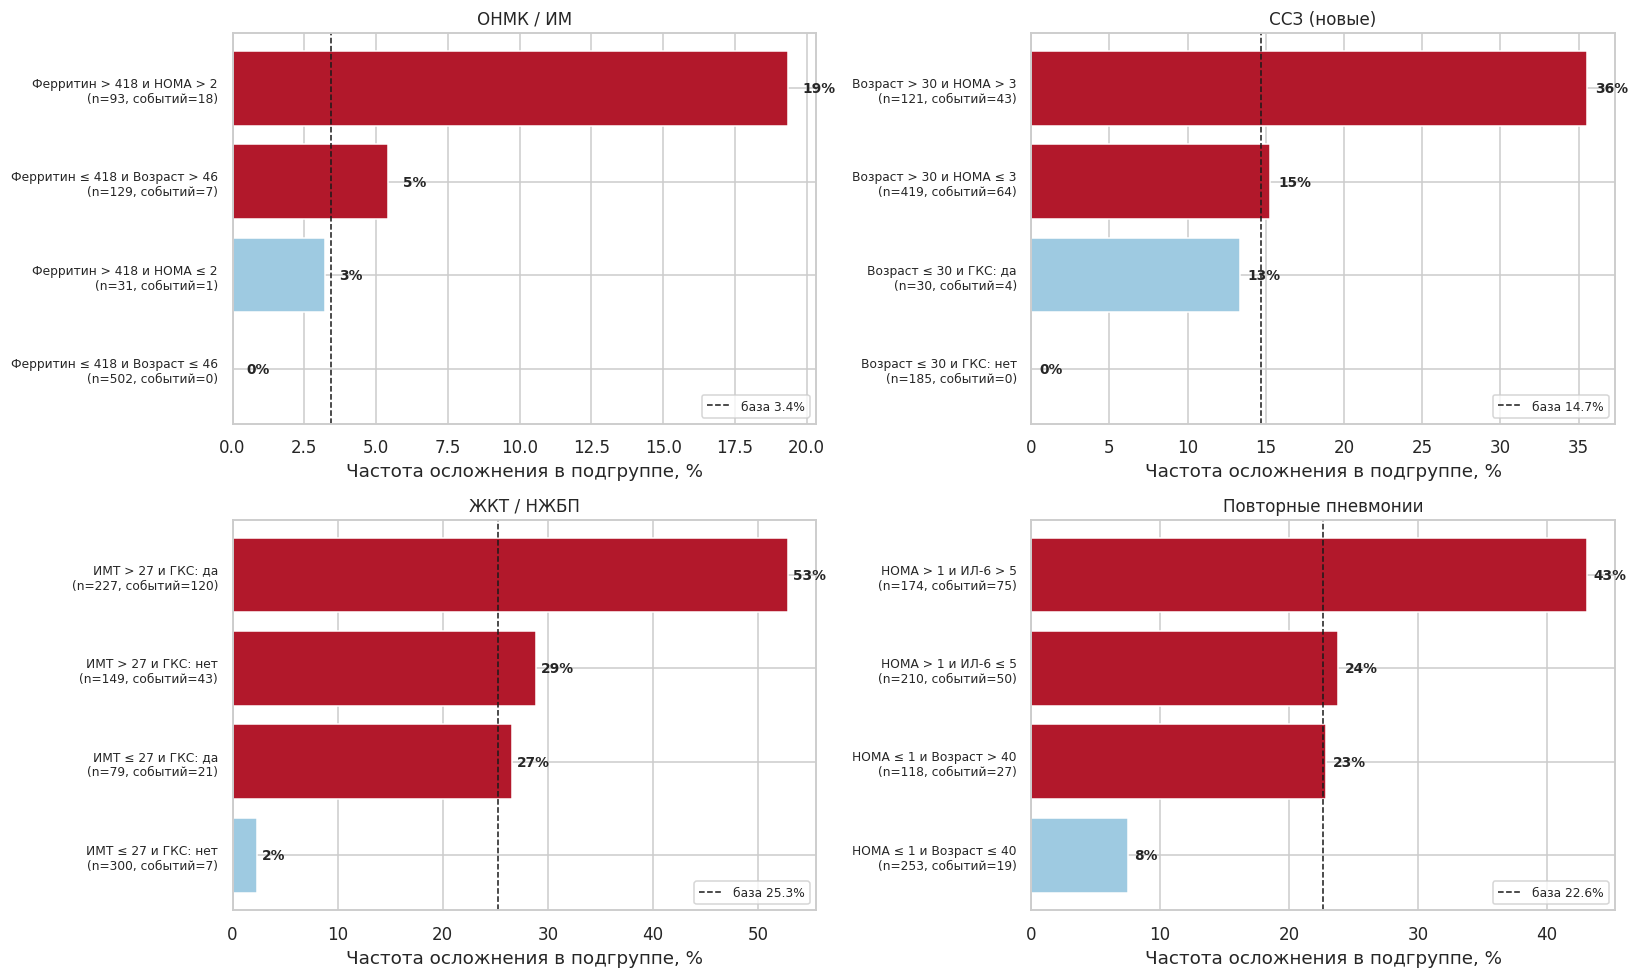

In [22]:
# --- детализация: все подгруппы для ключевых осложнений ---
KEY = ['ОНМК / ИМ', 'ССЗ (новые)', 'ЖКТ / НЖБП', 'Повторные пневмонии']
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, cname in zip(axes.ravel(), KEY):
    y = comp[cname]; base = y.mean()
    g = pd.DataFrame(risk_groups(y), columns=['Правило', 'N', 'Событий', 'Частота'])
    g = g.sort_values('Частота')
    colors = ['#b2182b' if r > base else '#9ecae1' for r in g['Частота']]
    ax.barh(range(len(g)), g['Частота'] * 100, color=colors)
    ax.axvline(base * 100, color='k', ls='--', lw=1, label=f'база {base*100:.1f}%')
    ax.set_yticks(range(len(g)))
    ax.set_yticklabels([f"{r}\n(n={n}, событий={e})" for r, n, e in
                        zip(g['Правило'], g['N'], g['Событий'])], fontsize=8)
    for i, (rate, n) in enumerate(zip(g['Частота'], g['N'])):
        ax.text(rate * 100 + 0.5, i, f'{rate*100:.0f}%', va='center', fontsize=9, fontweight='bold')
    ax.set_xlabel('Частота осложнения в подгруппе, %')
    ax.set_title(cname, fontsize=11); ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

Дерево решений выделяет клинически осмысленные группы риска: например, для **ОНМК/ИМ** ключевое
сочетание — высокий ферритин и инсулинорезистентность (HOMA), для **ЖКТ/НЖБП** — избыточная масса
тела и приём ГКС, для **повторных пневмоний** — инсулинорезистентность на фоне высокого ИЛ-6. Это
переводит статистические OR в практические критерии «кого относить к группе риска».

# ЭТАП 3. Клинико-лабораторный разбор конкретных примеров (SHAP)

Для каждого осложнения берём **репрезентативного пациента** с этим осложнением (ближайшего к центру
группы заболевших в пространстве лабораторных показателей) и объясняем предсказание модели методом
**SHAP** — так же, как в waterfall-разборе раздела 11.3 расширенного ноутбука.

Как читать диаграмму: внизу `E[f(x)]` — базовый (средний) риск осложнения по выборке, вверху
`f(x)` — итоговый риск для данного пациента. Каждая **стрелка** показывает вклад одного показателя:
**красная (вправо) повышает** риск, **синяя (влево) понижает**; слева подписано фактическое значение
показателя у пациента (напр. `СРБ = 142`). Сумма всех стрелок переводит базовый риск в итоговый.

> **Оговорка.** Для редких осложнений (ОНМК/ИМ, ХОБЛ/астма, СД, пневмофиброз — < ~50 событий)
> модель здесь обучается *в целях объяснения одного случая*, а не как валидированный прогноз
> (согласуется с принципом этапа 2.5). Waterfall показывает логику модели на конкретном пациенте,
> но величины вкладов для редких исходов следует трактовать качественно.

In [23]:
import shap

# робастный z-score лабораторных показателей — для выбора типичного пациента
iqr = (labs.quantile(0.75) - labs.quantile(0.25)).replace(0, 1.0)
zlab = (labs - labs.median()) / iqr

def representative_case(y):
    """Индекс наиболее типичного заболевшего (минимум расстояния до центра группы)."""
    pos = np.where(y.values == 1)[0]
    centroid = zlab.iloc[pos].mean()
    dist = ((zlab.iloc[pos] - centroid) ** 2).sum(axis=1)
    return dist.idxmin()

def patient_shap(rf, explainer, ridx):
    """SHAP-вклады по положительному классу для одного пациента (устойчиво к форме вывода)."""
    X_one = RG.loc[[ridx]]
    sv = explainer.shap_values(X_one, check_additivity=False)
    arr = np.array(sv)
    nf = RG.shape[1]
    if arr.ndim == 3:
        vals = arr[0, :, 1] if arr.shape[1] == nf else arr[1, 0, :]
    elif isinstance(sv, list):
        vals = sv[1][0]
    else:
        vals = arr[0]
    ev = explainer.expected_value
    base = float(ev[1]) if hasattr(ev, '__len__') else float(ev)
    return np.asarray(vals, dtype=float), base

print('Готово к построению SHAP-разборов')

Готово к построению SHAP-разборов


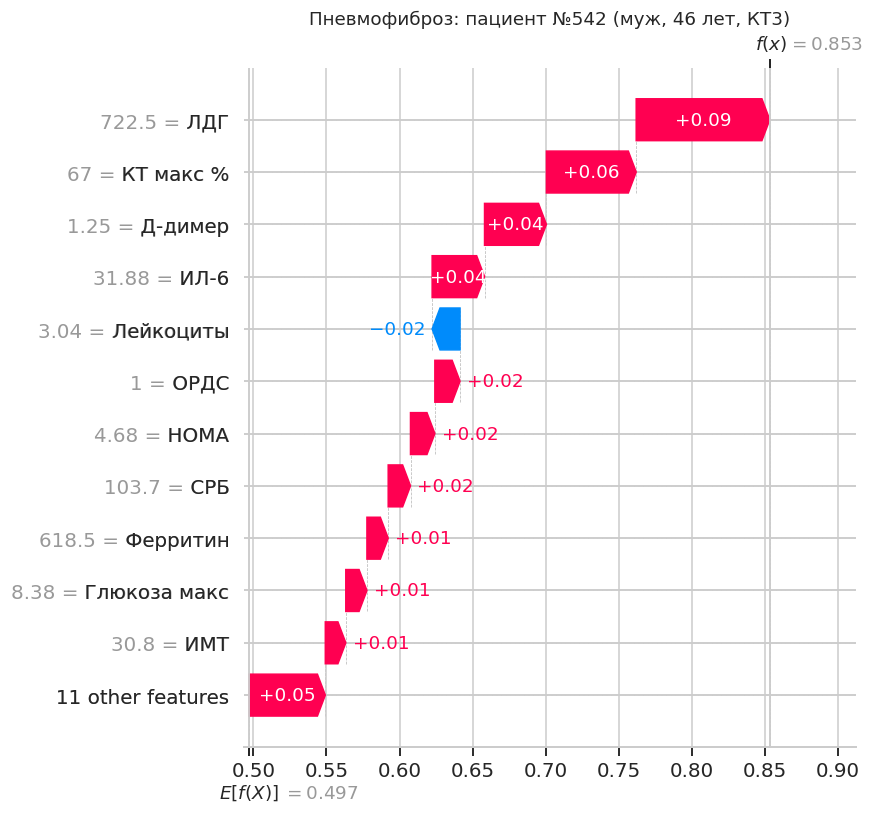

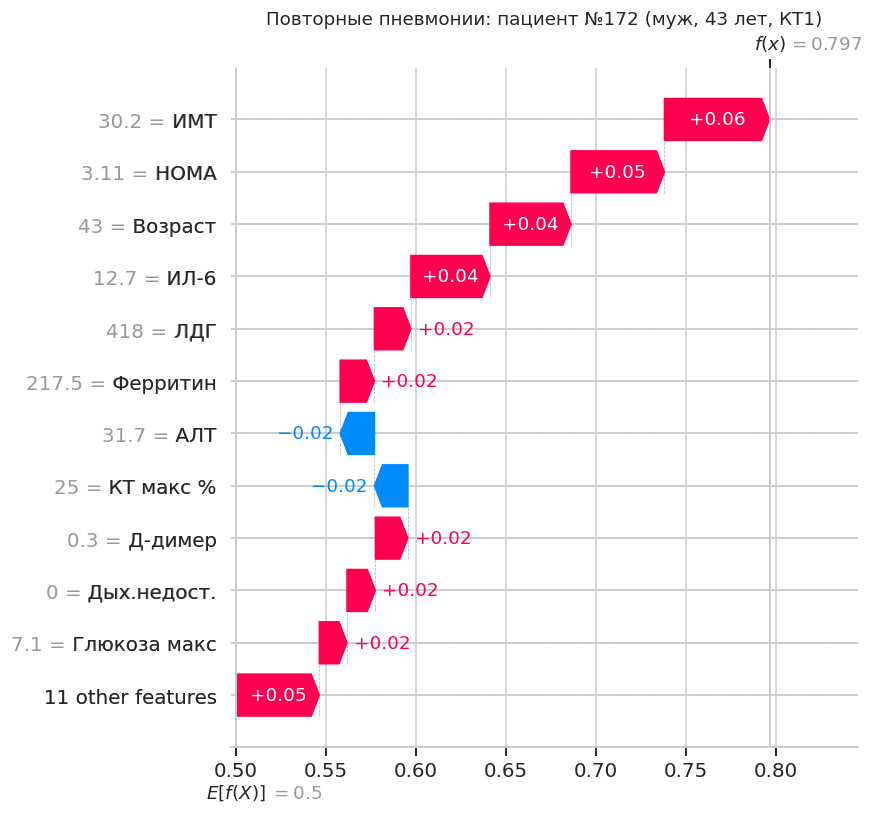

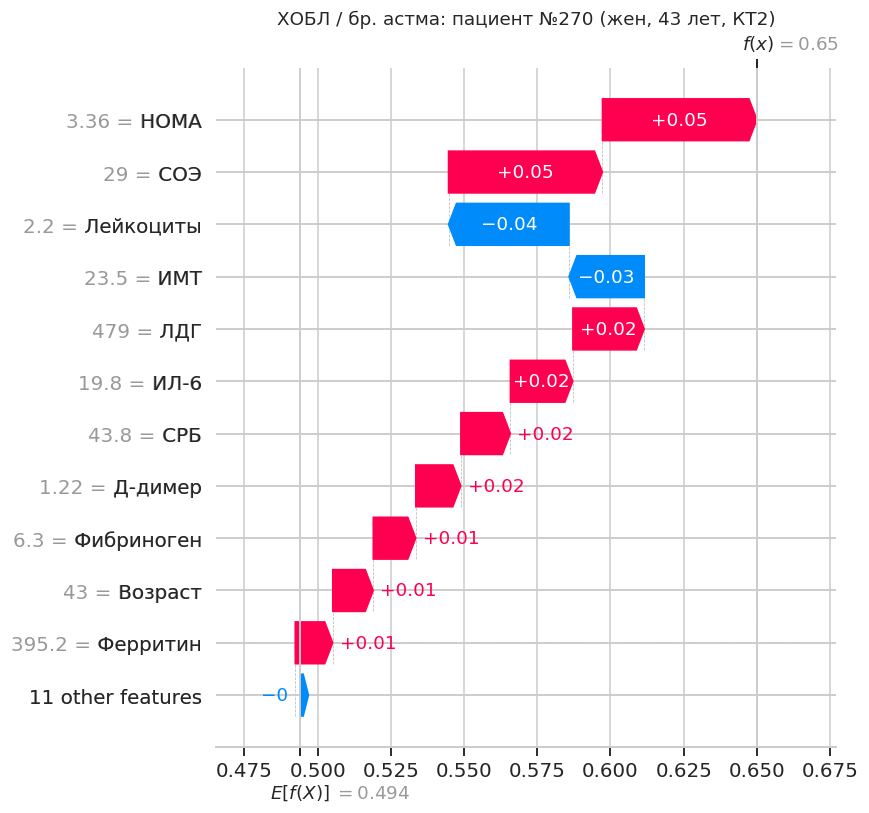

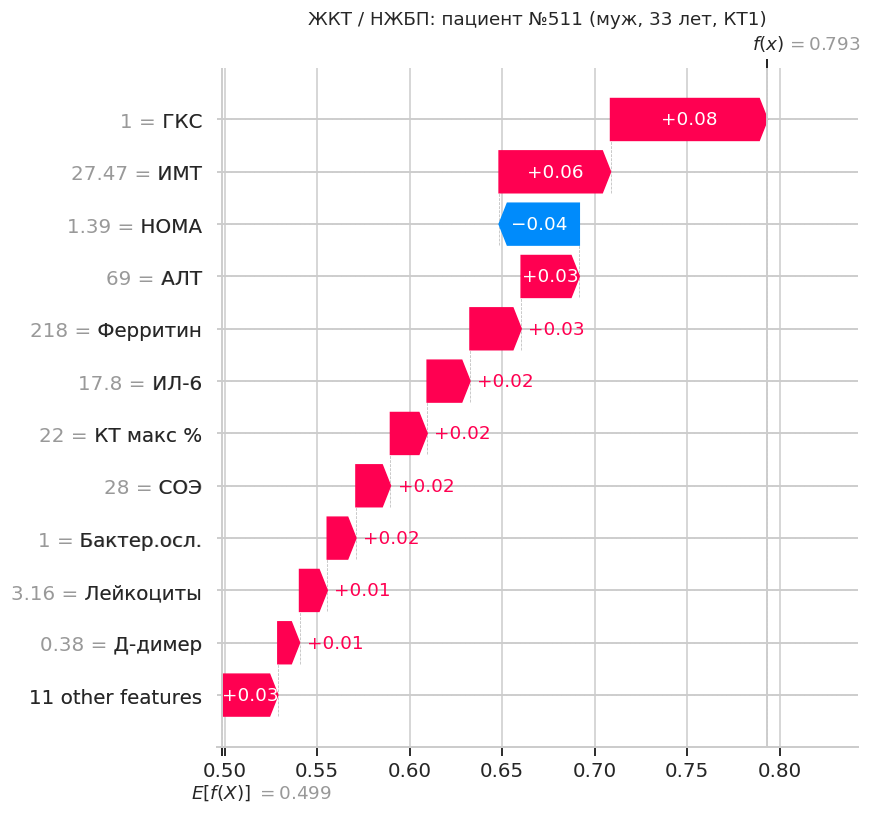

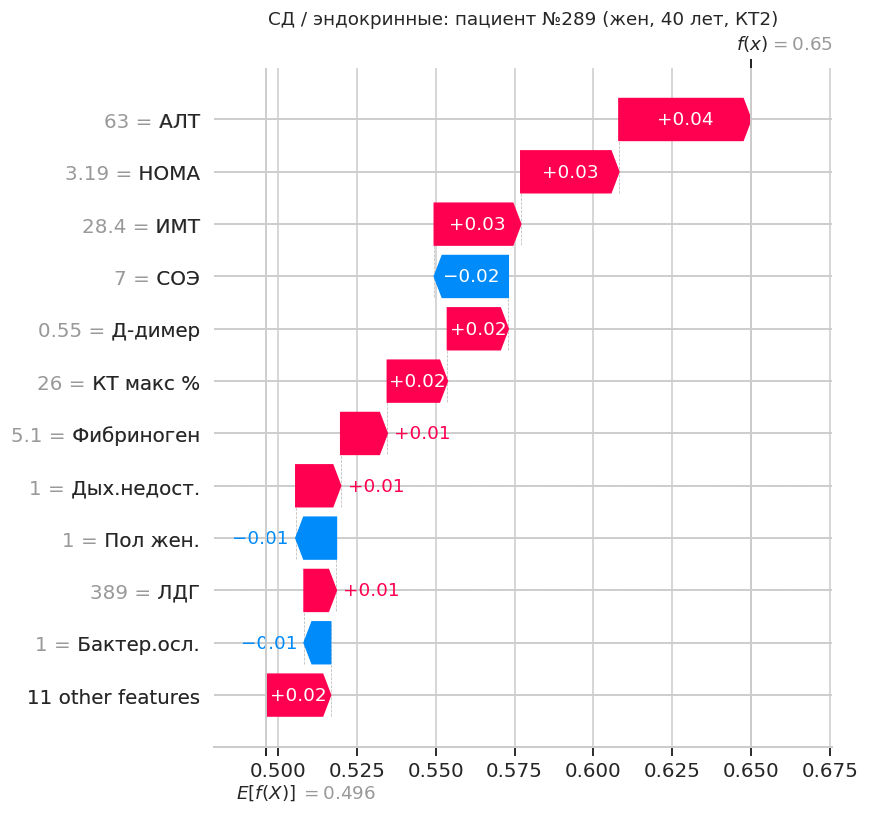

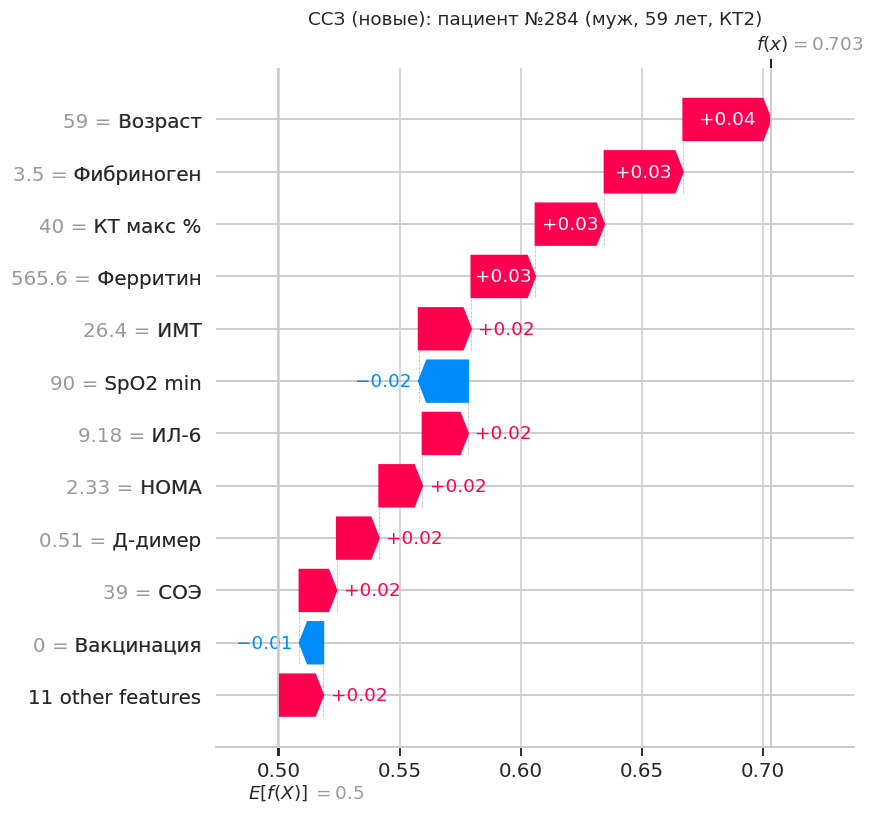

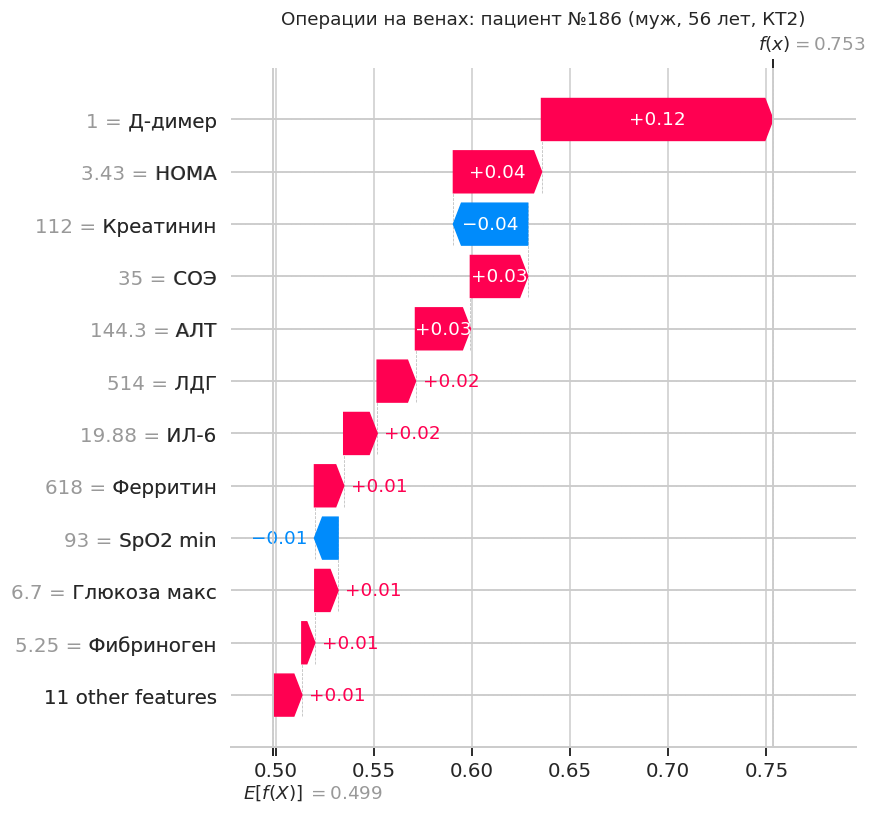

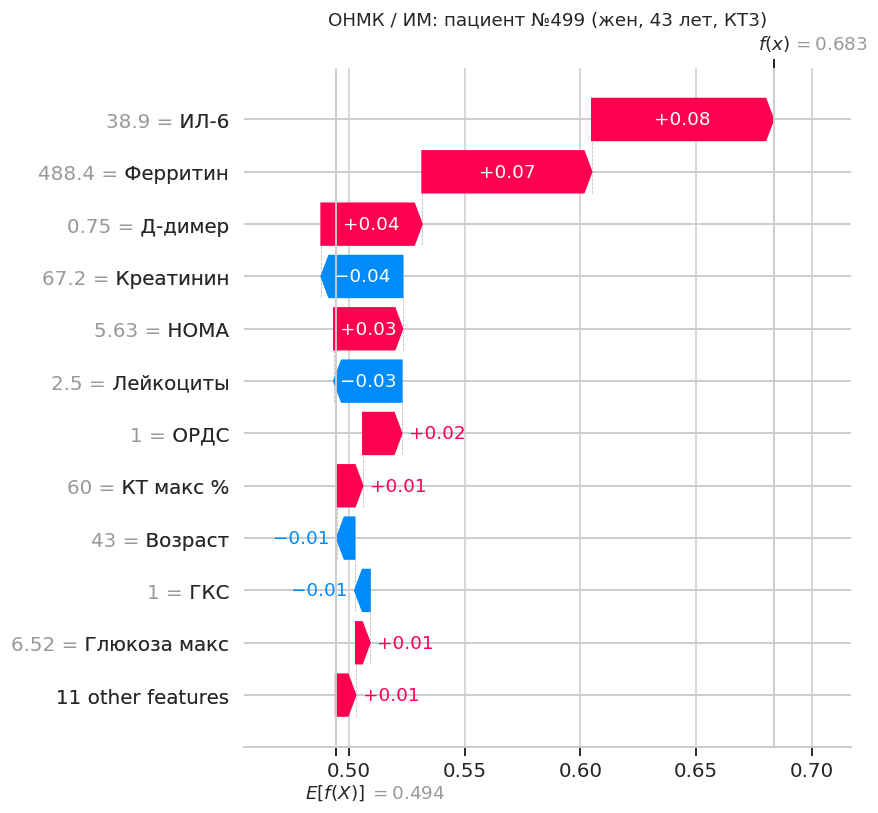

In [24]:
# waterfall-разбор репрезентативного пациента для каждого осложнения
comp8 = list(COMP_IDX.values())
for cname in comp8:
    y = comp[cname]
    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                random_state=RANDOM_STATE, n_jobs=-1).fit(RG, y)
    explainer = shap.TreeExplainer(rf)
    ridx = representative_case(y)
    vals, base = patient_shap(rf, explainer, ridx)

    age = labs.loc[ridx, 'Возраст']
    sex = 'жен' if (col(3) == 2).loc[ridx] else 'муж'
    kt_v = int(col(38).loc[ridx])

    explanation = shap.Explanation(values=vals, base_values=base,
                                   data=RG.loc[ridx].values, feature_names=list(RG.columns))
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f'{cname}: пациент №{ridx} ({sex}, {age:.0f} лет, КТ{kt_v})', fontsize=12)
    plt.tight_layout(); plt.show()

Waterfall-разбор показывает, какие именно показатели и в какую сторону «толкают» риск осложнения
у конкретного пациента, с их фактическими значениями. Видно, что у осложнений с
воспалительно-метаболическим механизмом (ОНМК/ИМ, ССЗ, ЖКТ/НЖБП) риск повышают высокие СРБ,
ферритин, ИЛ-6, глюкоза и HOMA, тогда как у фиброза и ХОБЛ/астмы — прежде всего тяжесть лёгочного
поражения (КТ, SpO2).

# ЭТАП 4. Прогнозирование панкреонекроза

Панкреонекроз — отдельно запрошенное осложнение. Оцениваем возможность его прогноза по имеющимся
данным.

In [25]:
PANCREO_IDX = 137
y_pn = binarize(PANCREO_IDX)
print(f'Панкреонекроз: {int(y_pn.sum())} случаев из {N} ({100*y_pn.mean():.1f}%)')

kt_num_pn = pd.Series(np.where(kt >= 3, 3, kt), index=df.index)
by_kt_pn = pd.DataFrame({
    'Всего': kt_num_pn.map(KT_LABELS).value_counts().reindex(kt_order),
    'Панкреонекроз': y_pn.groupby(kt_num_pn.map(KT_LABELS)).sum().reindex(kt_order).astype(int),
})
by_kt_pn['Частота, %'] = (100 * by_kt_pn['Панкреонекроз'] / by_kt_pn['Всего']).round(1)
print('\nРаспределение по тяжести КТ:')
display(by_kt_pn)

Панкреонекроз: 8 случаев из 755 (1.1%)

Распределение по тяжести КТ:


,Всего,Панкреонекроз,"Частота, %"
КТ0,303,3,1.000
КТ1,246,1,0.400
КТ2,142,0,0.000
КТ3-4,64,4,6.200


**Вывод о возможности прогноза.** В выборке всего **8 случаев** панкреонекроза. По правилу
«не менее 10 событий на один предиктор» обучение и валидация многопризнаковой прогнозной модели
статистически некорректны — любая такая модель переобучится и не будет воспроизводимой. К тому же
в данных нет панкреас-специфичных маркеров (амилаза, липаза). Поэтому вместо «модели-прогноза»
приводим **описательный разбор**: однофакторные ассоциации и клинико-лабораторные профили всех 8
пациентов.

In [26]:
# однофакторные ассоциации (осторожно: широкие ДИ из-за 8 событий)
rows = []
for name in FACTOR_NAMES:
    orr, lo, hi, p = or_univariate(y_pn, factors[name], name in CONT)
    rows.append((name, orr, lo, hi, p))
pn_uni = pd.DataFrame(rows, columns=['Фактор', 'OR', 'ДИ low', 'ДИ high', 'p'])
pn_uni = pn_uni[np.isfinite(pn_uni['OR'])].sort_values('p').head(8).reset_index(drop=True)
print('Факторы, наиболее ассоциированные с панкреонекрозом (разведочно):')
display(pn_uni)

Факторы, наиболее ассоциированные с панкреонекрозом (разведочно):


/home/user/code/covid_an/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Фактор,OR,ДИ low,ДИ high,p
0,АД сист.,2.695,1.534,4.735,0.001
1,ОРДС,9.671,2.367,39.518,0.002
2,АД диаст.,2.872,1.341,6.151,0.007
3,Температура,2.495,1.189,5.235,0.016
4,Сопут.: ССС,12.295,1.505,100.464,0.019
5,HOMA,1.480,1.015,2.157,0.041
6,ГКС (гормоны),4.470,0.896,22.295,0.068
7,ИМТ,1.736,0.919,3.277,0.089


In [27]:
# клинико-лабораторные профили всех пациентов с панкреонекрозом
pn_rows = np.where(y_pn.values == 1)[0]
profile = labs.loc[pn_rows].copy()
profile.insert(0, 'Пол', np.where((col(3) == 2).loc[pn_rows], 'жен', 'муж'))
profile.insert(1, 'КТ', col(38).loc[pn_rows].astype(int).values)
display(profile.T)

# сравнение средних: панкреонекроз vs остальные
cmp_tbl = pd.DataFrame({
    'Панкреонекроз (n=8)': labs.loc[pn_rows].mean().round(1),
    'Остальные': labs.loc[y_pn.values == 0].mean().round(1),
    'Медиана когорты': labs.median().round(1),
})
print('Средние значения показателей:')
display(cmp_tbl)

,187,230,245,272,300,482,514,539
Пол,муж,муж,муж,муж,муж,муж,жен,муж
КТ,3,3,0,3,3,0,1,0
Возраст,54,31,26,51,50,49,53,43
ИМТ,30.100,27.500,25.600,33.800,31.200,28.900,30.700,27.920
SpO2 min,88.000,90.000,96.000,87.000,78.000,95.000,95.000,94.000
КТ макс %,70,60,0,70,65,0,20,0
Лейкоциты,3.640,4.660,4.860,2.880,9.710,4.790,3.780,5.390
СОЭ,24,41,4,25,47,8,43,9
СРБ,89.720,85.600,3.490,80.700,106.800,5.300,25.200,13.200
Ферритин,614.000,525.000,54.600,253.400,529.000,38.600,162.000,213.500


Средние значения показателей:


,Панкреонекроз (n=8),Остальные,Медиана когорты
Возраст,44.600,37.800,39.000
ИМТ,29.500,27.100,26.900
SpO2 min,90.400,94.100,95.000
КТ макс %,35.600,16.500,10.000
Лейкоциты,5.000,5.000,4.600
СОЭ,25.100,18.300,15.000
СРБ,51.300,30.300,14.400
Ферритин,298.800,208.000,125.200
Д-димер,0.600,0.400,0.200
ЛДГ,461.000,336.900,299.000


Панкреонекроз встречается преимущественно при тяжёлом течении, но и при лёгком (3 из 8 — КТ0):
группа малочисленна и неоднородна. Сильных воспроизводимых предикторов на таком числе наблюдений
выделить нельзя; для построения прогнозной модели потребуется накопление случаев и добавление
панкреас-специфичных лабораторных маркеров.

# Выводы

**Этап 1 — тяжесть.** Частота всех поздних осложнений статистически значимо растёт с тяжестью
лёгочного поражения (тренд по КТ, p < 0.001 для каждого исхода). Сильнее всего от тяжести зависят
**пневмофиброз** (КТ0 0.7% → КТ3–4 ≈30%), **ОНМК/ИМ** (1% → 12.5%), **операции на венах** и
**ХОБЛ/астма**. ЖКТ/НЖБП и повторные пневмонии — самые частые исходы (25% и 23%), также нарастающие
с тяжестью.

**Основные признаки риска (любое осложнение).** По **однофакторным** OR сильнее всего с риском
связаны маркеры тяжёлого течения (ОРДС, ДН, бактериальные осложнения) и метаболический профиль.
В **многофакторной** модели независимый вклад сохраняют **возраст, HOMA, ГКС и ИМТ** — тогда как
ОРДС и ДН после поправки на них уже незначимы (их эффект объясняется корреляцией с этими факторами).
Значимого эффекта вакцинации на риск поздних осложнений не выявлено (OR≈1, p≈0.8).

**Этап 2 — группы риска (по OR-матрице и моделям):**

- **ОНМК/ИМ** — наиболее значимые факторы: **ОРДС** (резкое повышение шансов), пожилой **возраст**,
  высокий **HOMA** и сопутствующие ССЗ; группа максимального риска — пожилые пациенты с тяжёлым
  течением и метаболическими нарушениями.
- **ССЗ (новые)** — независимые факторы: **возраст, ИМТ, HOMA**. Преморбидные ССС-заболевания
  связаны с «новыми ССЗ» **обратно** (8% против 18%, adjusted OR≈0.03) — по-видимому, в силу
  определения исхода (впервые возникшие ССЗ у пациентов без них в анамнезе), поэтому как фактор
  риска их трактовать нельзя.
- **ЖКТ / НЖБП** — ведущий независимый фактор **применение ГКС** (OR≈5.6), далее избыточная масса
  тела (ИМТ) и HOMA.
- **Повторные пневмонии** — по многофакторной модели значимы возраст, ГКС и бактериальные осложнения;
  ДН после поправки имеет **обратный** знак (OR≈0.37) и фактором риска не является.
- **Пневмофиброз / ХОБЛ-астма** — по однофакторным OR прежде всего тяжесть течения (ОРДС, ДН) и КТ.

**Группы риска (этап 2.6).** Деревья решений выделяют конкретные подгруппы с многократно повышенным
риском, например: ОНМК/ИМ — высокий ферритин + инсулинорезистентность (HOMA), риск ≈19% (×5–6 к
базовому); ЖКТ/НЖБП — избыточная масса тела + ГКС (≈53%); повторные пневмонии — HOMA + высокий ИЛ-6
(≈43%). Это переводит ассоциации в практические критерии отбора в группу риска.

**Клинико-лабораторный разбор (этап 3).** Для каждого осложнения разобран профиль типичного
пациента: воспалительно-метаболические осложнения (ОНМК/ИМ, ССЗ, ЖКТ/НЖБП) сопровождаются ростом
СРБ, ферритина, ИЛ-6, глюкозы и HOMA; фиброз и ХОБЛ/астма — в первую очередь тяжестью лёгочного
поражения (КТ, SpO2).

**Панкреонекроз (этап 4).** Всего 8 случаев — для воспроизводимой прогнозной модели данных
недостаточно (нужно ≥10 событий на предиктор и панкреас-специфичные маркеры). Приведён описательный
разбор; прогноз станет возможен по мере накопления случаев.

**Методическое замечание.** Следует различать два режима. *Прогностические* метрики (этап 2.5) даны
с кросс-валидацией и только для частых исходов. Деревья групп риска (2.6) и SHAP-разбор (3) применены
ко всем осложнениям, включая редкие, но в **описательно-объяснительном** режиме (in-sample, без
валидации) — это интерпретация выявленных закономерностей, а не готовый прогноз. Наборы предикторов
в OR-анализе (течение + коморбидность) и в деревьях/SHAP (с лабораторными показателями) различаются и
**дополняют** друг друга. Все выводы носят ассоциативный характер (наблюдательные данные) и требуют
клинической верификации.
